# Neural Networks Week 1

This week we will briefly introduce the concept of Neural Networks and their components using a 'human-brain' example. Next session we will work to build a basic Neural Network on a wind energy example using Python, before going into the technical parts of architecture and training in the final 2 sessions of this section.

## Concept
Neural Networks are computational methods designed to mimic how the human brain works by building a network of interconnected 'neurons' which can process and communicate information between them. You may also hear them referred to as:
- Artificial Neural Networks
- Neural Nets

Neural Networks can simulate complex relationships between numerical inputs and outputs. Since almost all data can be converted into numerical information, this is fairly limitless. Natural language (text) data, such as PDF documents, typed text chat, audio etc., images, and even video can be translated into numerical vector format in order to be processed and modelled with Neural Networks. 

NNs are incredibly diverse and flexible, ranging from highly-efficient simple models which run quickly and effectively, to complex transformer models such as those that form the basis of generative AI models like ChatGPT. For this section of the course we will just be referring to *Feed-forward Neural Networks (FNNs)*. These are also referred to as *multi-layer perceptrons*, or Fully-connected Neural Networks. These are the simplest types of Neural Networks. Later in the course we will cover alternative, more complex architectures suited to deep-learning.

## Structure
A Feed-forward Neural Network can be thought of like a factory conveyor belt. The 'feed-forward' part of the name refers to the fact that information only moves in one direction - forward. Inputs are put on one end of the conveyor belt, they travel forward through hidden processes in the middle, and output predictions come out of the other end. 

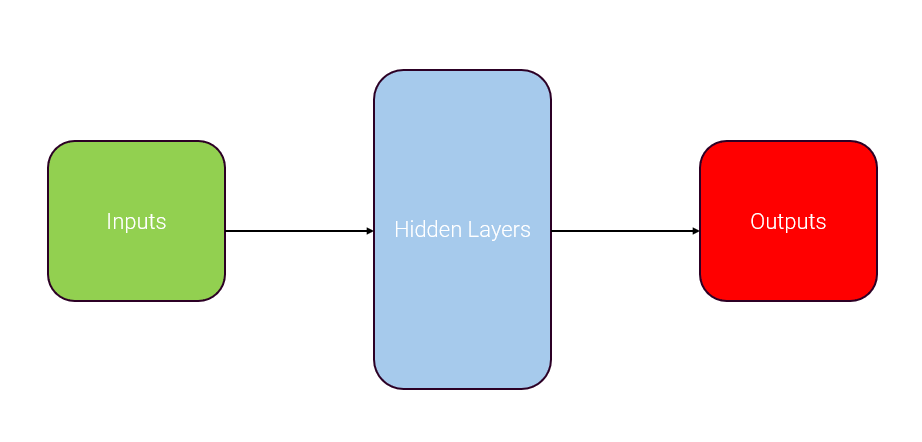.

This idea is why Neural Networks (and similar methods) are sometimes referred to as 'black-box models', since the processes that happen in the middle are sometimes considered to be 'hidden' or difficult to interpret.
Some FNNs have several hidden layers with hidden processes occurring, like below,

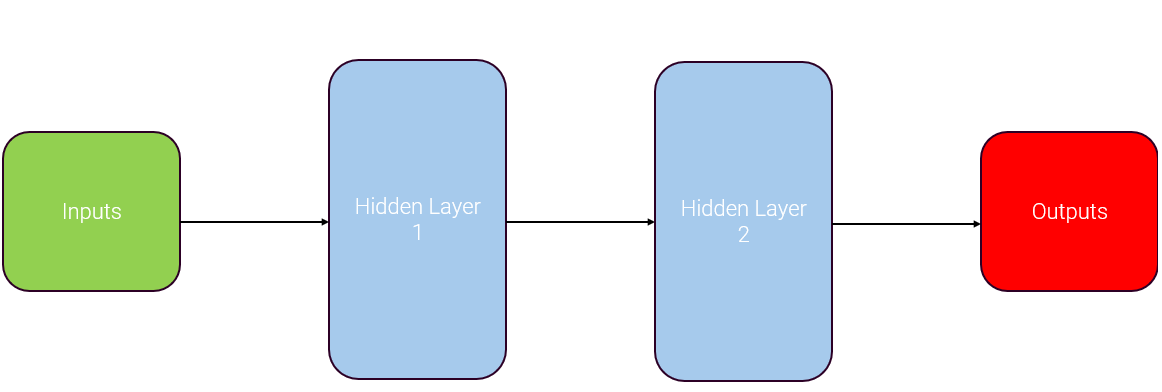

but for the example in this session we will focus on a single-layered Feed-forward Neural Network. In reality the architecture is a little more complex than a simple in -> box -> out, we can see a more expanded example below. Input and output can be made up of several features, and within the hidden layer we have processing units known as *nodes*, represented by blue circles in the image below. Here we have 5 input features, 2 nodes, and 1 output feature, but these numbers will change depending on our model structure. Input features, nodes, and output features are connected by *edges*, here represented by arrows. As this is a *Feed-forward* Neural Network we see all of these edges are going in the same direction (forward, or input to output direction), with no recursion. We will go through what each component of the structure represents, and how information flows through the system.
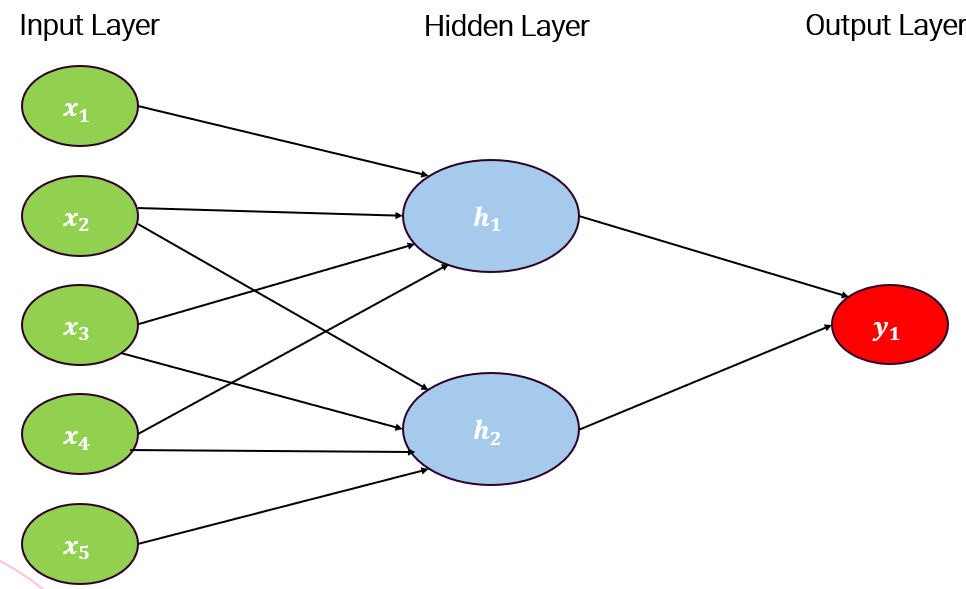


## Input Layer
The input layer, represented by the green circles, is simply the data we are inputting into the system. Each of these green circles represents an *input feature*. In the human brain, these input features may be the stimuli we are experiencing. At any given time we are taking in 5 main features: gustation (taste), olfaction (smell), tactile (touch), visual (sight), and auditory (sound). These are the input features we will be using in the following example, raw signals coming in from the data we receive through these senses:
\begin{align}
x_1 &= \text{ taste}\\
x_2 &= \text{ smell}\\
x_3 &= \text{ touch}\\
x_4 &= \text{ sight}\\
x_5 &= \text{ sound}.
\end{align}

## Hidden Layers and Nodes
Each hidden layer is made up of several *nodes*. These nodes are the part of the system mimicking *neurons*. Nodes take in information from the previous layer in the system (as we can see represented by arrows), process this information, and then communicate the information to the next layer. Let's breakdown these three steps.

### Information Absorption and Edges
What information does a node take in? Let's think about how neurons in the human brain work. When we receive stimuli it triggers certain neurons to fire, but not all neurons will be receiving the same information or reacting to all stimuli. We have 5 different featues being received (taste, smell, touch, sight and sound). Some parts of the brain, like those managing the autonomic nervous system, will take in information from each of these features. However, it will prioritise some of these. Our autonomic nervous system prioritises touch over the other features. Other processes, such as how we taste and enjoy food will take in only some information. In this case, information from taste, smell, touch as well as sight will be taken in but sound will likely not be a factor. For most people the priority, or weighting, will be in that order, with taste being the most important, then smell, then touch, and only a little importance on the sight. If we focus on this food experience neuron, it will be intaking information from all the input features except for sound, so the flow of information will look like this:

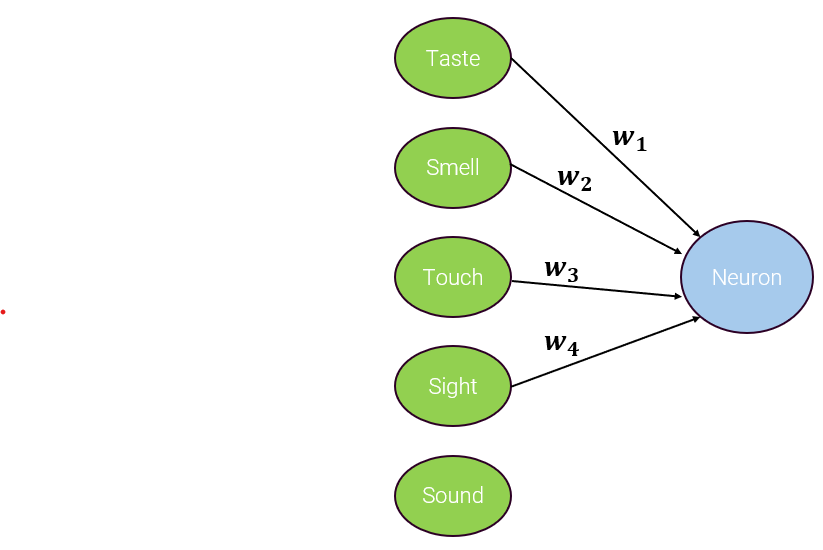

with arrows representing connections (*edges*) between the input features and the node. We can see there are edges between the first four input features (taste, smell, touch and sight), but not from the fifth input (sound).
Each edge has an associated *weight*, $w_i$, representing how the features are being prioritised by the node. Here $w_1$ will have the highest weight as taste is most important, diminishing down to $w_4$ as sight is the least important.

Let's translate this to a real Neural Network System. We have several features from the previous layer (this may be the input layer, or it may be a previous hidden layer). Each node takes in information from a set of these features (this may be all the features, or a subset of them), and prioritises them. The way this is done is by multiplying the vector of input features by their associate weights, and summing with a bias. Mathematically:

$$\begin{bmatrix}
    x_1\\
    x_2\\
    x_3\\
    x_4
\end{bmatrix}\rightarrow w_1\cdot x_1 + w_2\cdot x_2 + w_3 \cdot x_3 + w_4 \cdot x_4 + b.$$
This is the first stage of what happens in a neuron process, we have absorbed and filtered information from the previous layer into useful data relevant to the process within this neuron.

### How are the weights determined?
In simple terms we compare the predicted output of a network to the true expected output and use this information to optimise the weights of the system through an iterative learning process conducted on training data. In the case of *supervised learning*, training data will consist of labelled input-output pairs. The network will be provided with input data, and have its output compared to the true value. The difference in the estimated and true outputs will be used to adjust the weights accordingly. The way in which they are adjusted is determined by a *learning rule*.
For example if we start with initial weights:
$$\begin{bmatrix}
    x_1\\
    x_2\\
    x_3\\
    x_4
\end{bmatrix}=\begin{bmatrix}
    0\\
    0\\
    0\\
    1
\end{bmatrix},$$
we are putting all our weight on sight only. If we eat several meals we are going to realise that this is not a good method of determining if we are going to enjoy our meal, so we may begin reducing this weight and increasing the weight of the other parameters. We can measure how much we improve our predictions as we increase each weight, and we will likely soon realise that taste is the most important feature so this one will eventually be increased to the highest value. This is a (very big) simplification of a method known as *Stochastic Gradient Descent*, the typical method to train weights within a Neural Network. To carry out this method we define a loss function, $\mathcal{L}$, to quantify the quality of estimated output when compared to the true values of the training data, e.g. mean squared error
$$\mathcal{L}=\frac{1}{n}\sum^n_{i=1}\left(\hat{y}_i-y_i\right)^2.$$
The adjustments to the weights after training is calculated as 
$$w_i = w_i -\nu \frac{\delta \mathcal{L}}{\delta w},$$
where $\nu$ is the *learning rate* and $\frac{\delta \mathcal{L}}{\delta w_i}$
is the partial derivative of the loss function with respect to weight $i$. The partial derivative of the loss function helps us understand how much we improve our predictions (or reduce our loss) as we change the weight. This value is usually calculated through *back-propagation*, working backwards through the network to infer the relationship between the weights and the loss. If this derivative is positive, then increasing it will increase the loss function. If it is negative, then increasing it will decrease the loss function. Thus, iterating the weights using this measure will gradually decrease the error until the model is sufficiently accurate.

## Information Processing
The next stage within the node is processing. This stage takes in the equation and carries out an *activation function*, usually a relatively simple equation which translates a large range of possible inputs into a more controlled set of outputs. This function is used to convert a complex, and possibly unbounded input made up of several combined features, into a simple output with a predictable form. For example, let's revisit our food experience example. Let's imagine our internal model is trying to determine whether or not our meal is enjoyable. The input information was very complicated, made up of information from four different features. We have distilled this information into a numerical format by multiplying each input signal by their weights. However, if someone asked us if we were enjoying our meal and we replied with a numerical vector this probably wouldn't be very helpful. It would be more useful if we had a binary yes or no answer, numerically 1 might represent 'yes the meal is nice' and 0 might represent 'no the meal is not nice'. 

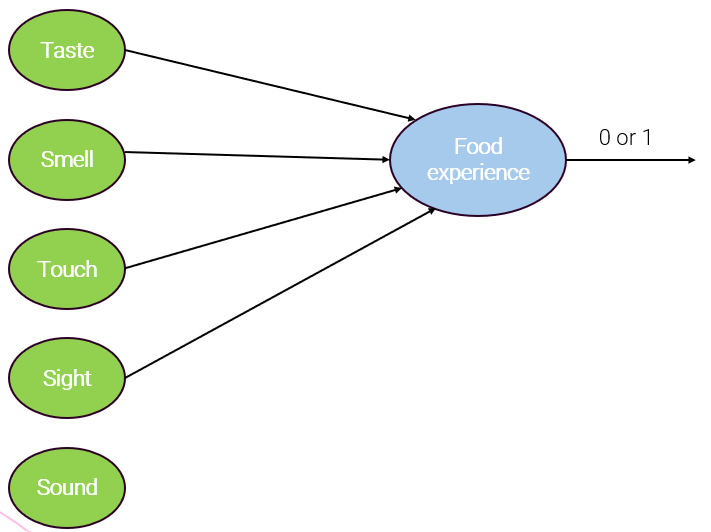

Here our activation function would have some relationship where it would map numerical vectors to either 1 or 0. Some activation functions are like this, where there is a binary or categorical output, but it is more common to have activation functions which instead output continuous values within a range such as 0 to 1, which may have an interpretation such as probability if they are an output feature. We will go into depth on different activation functions next week. 

## Information Outputting
The outputs of the previous node are now confined to be of a nice, bounded form for outputting to the next layer. This information will be outputted and connected to nodes in the next layer (this could be another hidden layer, or an output layer) by edges, with some associated weight, to be combined and processed with other outputs from this layer. For example, if we are trying to determine whether or not we like the restaurant we are eating at we may combine the information from our food experience node, with a node processing the experience of the restaurant environment. Both take in complex input, process them to a simple positive or negative (1 or 0) output. We then weight them again and combine them to get our output. If the food experience is more important this is weighted higher before it is moved on to the next layer. In this case there is only one hidden layer, so our next layer is our output layer: a single output feature determining whether or not we have enjoyed our restaurant experience.

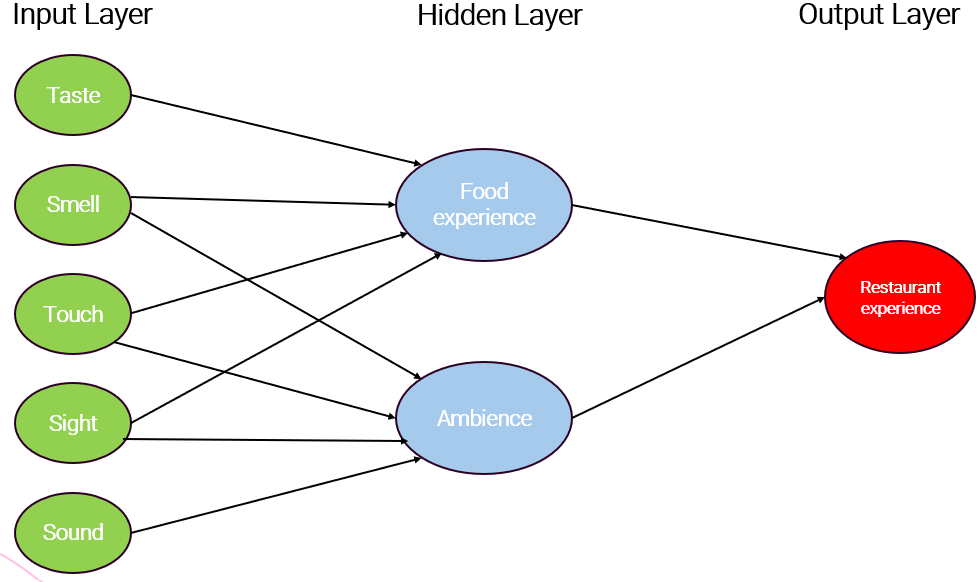

We have now seen an end-to-end example of a Neural Network structure. Next week we will build one using Python code within the context of wind energy. Neural Networks are one of the most abstract models we will cover in this course and lots of this might not make sense straight away. Building one in practice will help to solidify some of these concepts - but in the meantime please feel free to reach out with any questions as there is a lot to absorb!